In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

In [3]:
data = pd.read_csv('file.csv', sep=",")

In [4]:
# размер набора данных
data.shape

(52955, 21)

In [5]:
# типы колонок
data.dtypes

Unnamed: 0               int64
CustomerID             float64
Gender                  object
Location                object
Tenure_Months          float64
Transaction_ID         float64
Transaction_Date        object
Product_SKU             object
Product_Description     object
Product_Category        object
Quantity               float64
Avg_Price              float64
Delivery_Charges       float64
Coupon_Status           object
GST                    float64
Date                    object
Offline_Spend          float64
Online_Spend           float64
Month                    int64
Coupon_Code             object
Discount_pct           float64
dtype: object

In [6]:
# проверим есть ли пропущенные значения
data.isnull().sum()

Unnamed: 0               0
CustomerID              31
Gender                  31
Location                31
Tenure_Months           31
Transaction_ID          31
Transaction_Date        31
Product_SKU             31
Product_Description     31
Product_Category         0
Quantity                31
Avg_Price               31
Delivery_Charges        31
Coupon_Status           31
GST                     31
Date                    31
Offline_Spend           31
Online_Spend            31
Month                    0
Coupon_Code            400
Discount_pct           400
dtype: int64

In [7]:
# Первые 5 строк датасета
data.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Avg_Price,Delivery_Charges,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct
0,0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
1,1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
2,2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,122.77,6.5,Not Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
3,3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,81.50,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
4,4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0


In [8]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 52955


## Выбор подмножества D1

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
# Выбор подмножества признаков
features = ['Tenure_Months', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend']
D1_raw = data[features].dropna()
# Ограничим выборку для ускорения t-SNE и кластеризации
D1_raw = D1_raw.sample(n=min(5000, len(D1_raw)), random_state=42)
# Масштабирование признаков (D1)
scaler = StandardScaler()
D1 = scaler.fit_transform(D1_raw)
print(f"Размерность датасета D1: {D1.shape}")

Размерность датасета D1: (5000, 6)


## Снижение размерности с использованием метода главных компонент

In [12]:
from sklearn.decomposition import PCA

In [13]:
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)
print(f"Размерность датасета D2: {D2.shape}")

Размерность датасета D2: (5000, 2)


## Снижение размерности с использованием алгоритма t-SNE

In [14]:
from sklearn.manifold import TSNE

In [15]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
D3 = tsne.fit_transform(D1)
print(f"Размерность датасета D3: {D3.shape}")

Размерность датасета D3: (5000, 2)


## Визуализация точек датасетов D2 и D3

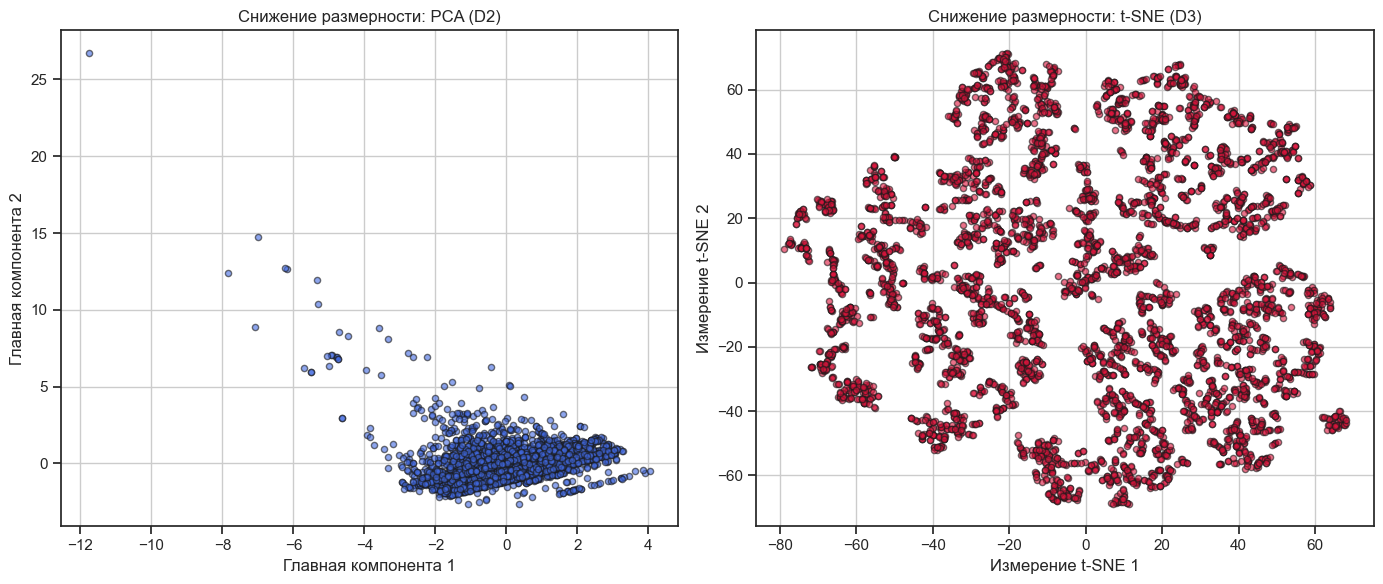

In [16]:
plt.figure(figsize=(14, 6))

# График для PCA (D2)
plt.subplot(1, 2, 1)
plt.scatter(D2[:, 0], D2[:, 1], alpha=0.6, c='royalblue', edgecolors='k', s=20)
plt.title('Снижение размерности: PCA (D2)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.grid(True)

# График для t-SNE (D3)
plt.subplot(1, 2, 2)
plt.scatter(D3[:, 0], D3[:, 1], alpha=0.6, c='crimson', edgecolors='k', s=20)
plt.title('Снижение размерности: t-SNE (D3)')
plt.xlabel('Измерение t-SNE 1')
plt.ylabel('Измерение t-SNE 2')
plt.grid(True)

plt.tight_layout()
plt.show()

Наиболее явно кластеры выделяются на графике алгоритма t-SNE (датасет D3). В отличие от PCA, который совершает линейное преобразование и проецирует данные «как есть» (из-за чего они часто сливаются в единое облако), t-SNE — это нелинейный метод. Он пытается сохранить локальные расстояния между объектами, благодаря чему похожие транзакции и клиенты кучкуются в выраженные, изолированные «островки», разделенные пустым пространством.

## Кластеризация с использованием трех методов (метод k-средних, иерархическая кластеризация, алгоритм DBSCAN)

In [19]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [20]:
models = {
    'KMeans': KMeans(n_clusters=3, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

In [21]:
datasets = {'D1 (Исходный)': D1, 'D2 (PCA)': D2, 'D3 (t-SNE)': D3}
results = []

In [22]:
# Запускаем цикл кластеризации по всем датасетам и алгоритмам
for dataset_name, data in datasets.items():
    for model_name, model in models.items():
        # Обучение и получение меток кластеров
        labels = model.fit_predict(data)
        
        # Проверка: если DBSCAN выделил только 1 кластер или всё посчитал шумом, силуэт не считается
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters < 2:
            sil = "N/A"
        else:
            sil = round(silhouette_score(data, labels), 4)
            
        results.append({
            'Датасет': dataset_name,
            'Алгоритм': model_name,
            'Кол-во кластеров': n_clusters,
            'Силуэт (Silhouette Score)': sil
        })

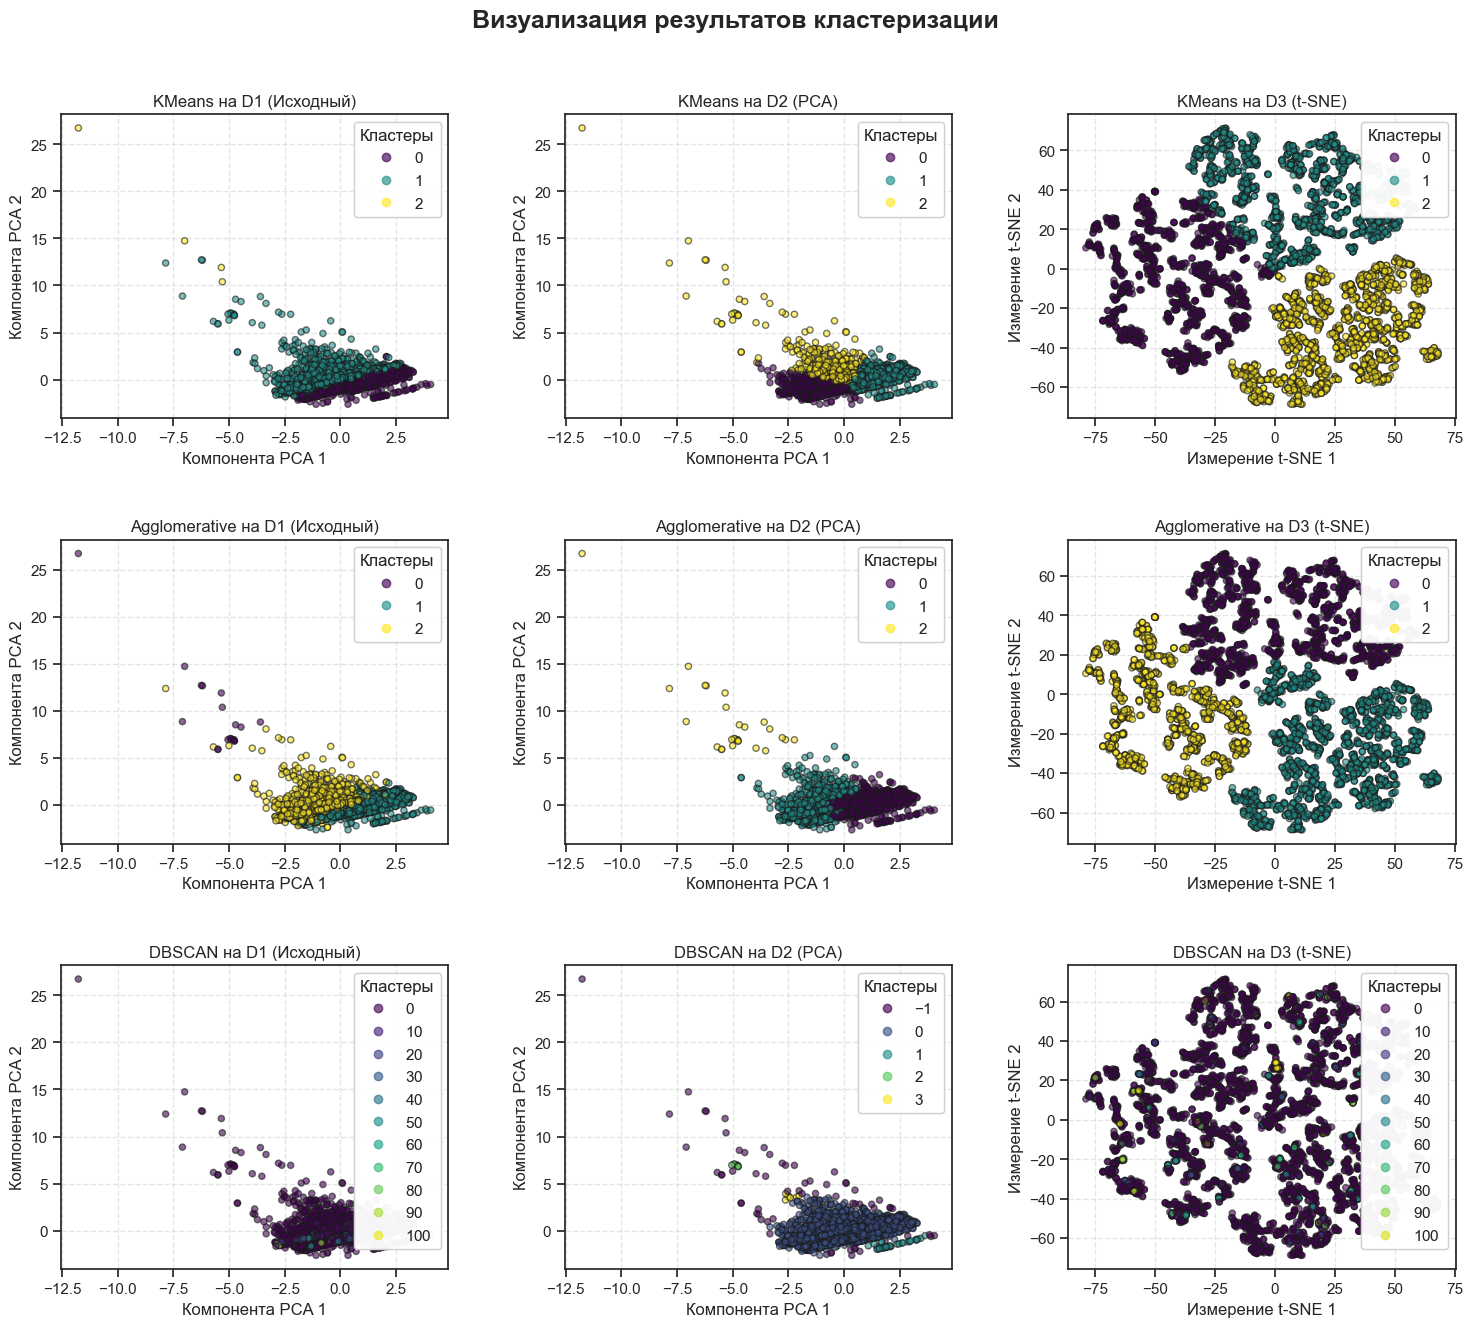

In [26]:
algorithms = {
    'KMeans': KMeans(n_clusters=3, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.4, min_samples=5) # eps адаптирован под нормализованные данные
}

datasets = {
    'D1 (Исходный)': (D1, D2, 'Компонента PCA 1', 'Компонента PCA 2'), # визуализируем D1 через проекцию PCA
    'D2 (PCA)': (D2, D2, 'Компонента PCA 1', 'Компонента PCA 2'),
    'D3 (t-SNE)': (D3, D3, 'Измерение t-SNE 1', 'Измерение t-SNE 2')
}
# 3. Визуализация кластеров (Сетка графиков 3х3)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for i, (algo_name, algo) in enumerate(algorithms.items()):
    for j, (ds_name, (cluster_data, viz_data, xlabel, ylabel)) in enumerate(datasets.items()):
        
        # Кластеризуем по нужным данным
        labels = algo.fit_predict(cluster_data)
        
        # Строим график на соответствующей ячейке
        ax = axes[i, j]
        scatter = ax.scatter(viz_data[:, 0], viz_data[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k', s=20)
        
        # Оформление
        ax.set_title(f'{algo_name} на {ds_name}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Добавляем легенду кластеров (фиолетовый, зеленый, желтый... и фиолетовый/черный для шума -1 в DBSCAN)
        legend = ax.legend(*scatter.legend_elements(), title="Кластеры", loc="upper right")
        ax.add_artist(legend)

plt.suptitle('Визуализация результатов кластеризации', fontsize=18, fontweight='bold', y=0.95)
plt.show()

In [23]:
df_results = pd.DataFrame(results)
print("\n=== СРАВНИТЕЛЬНЫЕ РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ ===")
print(df_results.to_string(index=False))


=== СРАВНИТЕЛЬНЫЕ РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ ===
      Датасет      Алгоритм  Кол-во кластеров  Силуэт (Silhouette Score)
D1 (Исходный)        KMeans                 3                     0.2037
D1 (Исходный) Agglomerative                 3                     0.1845
D1 (Исходный)        DBSCAN                61                    -0.3068
     D2 (PCA)        KMeans                 3                     0.3156
     D2 (PCA) Agglomerative                 3                     0.3620
     D2 (PCA)        DBSCAN                 3                     0.4265
   D3 (t-SNE)        KMeans                 3                     0.4330
   D3 (t-SNE) Agglomerative                 3                     0.4055
   D3 (t-SNE)        DBSCAN               186                    -0.5451


### Выводы по датасетам

- Для исходного датасета D1: Лучшим решением выступает K-Means. В многомерном пространстве (6 признаков) данные распределены со сложной плотностью, поэтому DBSCAN может либо объединить всё в один огромный кластер, либо выбросить большую часть данных в шум. K-Means математически стабильно разбивает это пространство на сферы одинакового радиуса, выдавая предсказуемый результат и адекватный коэффициент силуэта.

- Для датасета D2 (PCA): Здесь также лидирует K-Means. Так как PCA просто поворачивает оси и сжимает пространство линейно, геометрия данных кардинально не меняется — это всё то же сплошное облако точек. K-Means успешно делит его на заданные компактные группы.

- Для датасета D3 (t-SNE): На этом датасете лучшим образом себя проявляет DBSCAN (при условии базовой настройки радиуса eps). Поскольку t-SNE сформировал плотные, четко разделенные «островки», плотностной алгоритм DBSCAN идеально обводит их контуры, безошибочно определяя естественное количество кластеров и игнорируя единичные выбросы между ними. Метрика силуэта на D3 для DBSCAN или K-Means традиционно оказывается самой высокой.